# **HW6: SQL and Data Cleaning**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Working with Corrupted Data: SQL and Data Cleaning**

In this notebook exercise, we will combine two essential data science skills: **SQL for data storage and retrieval** and **data cleaning techniques** to handle real-world data quality issues.

## **The Real-World Problem**

In practice, data is rarely clean when you first receive it. Data quality issues can arise from:
- **Human error**: Manual data entry mistakes, typos
- **System failures**: Sensor malfunctions, database corruption
- **Integration issues**: Merging data from multiple sources
- **Missing information**: Incomplete records, non-responses

Before you can build models or perform analysis, you must:
1. **Store and organize** your data (using databases and SQL)
2. **Identify** data quality issues (using SQL queries and pandas)
3. **Clean** the data (handling missing values, duplicates, outliers, etc.)
4. **Validate** the cleaning process (comparing before/after)

## **What You'll Learn**

### **SQL Skills:**
- Creating SQLite databases and tables
- Inserting data into databases
- Querying with SELECT, WHERE, COUNT, DISTINCT
- Using aggregate functions (AVG, MIN, MAX)
- Detecting data quality issues with SQL

### **Data Cleaning Skills:**
- **Missing values**: Detection and imputation strategies
- **Duplicates**: Identifying and removing duplicate records
- **Inconsistent values**: Finding and correcting category errors
- **Outliers**: Using IQR (Interquartile Range) to detect anomalies
- **Validation**: Comparing data before and after cleaning

## **The Dataset**

We'll use the **Wine Quality dataset** from scikit-learn, which contains chemical properties of wines. However, we've **intentionally corrupted** this dataset with various data quality issues that you'll need to identify and fix.

The dataset includes features like:
- Alcohol content
- Acidity levels
- Sugar content
- Color (categorical: red/white/rosé)

## **Your Mission**

You will:
1. Load corrupted wine data from a SQLite database
2. Use SQL queries to explore and detect data quality issues
3. Apply data cleaning techniques to fix each issue
4. Save the cleaned data back to the database
5. Validate your cleaning with SQL queries and visualizations

## **Import Libraries**

Let's start by importing the necessary libraries for data manipulation, database operations, and visualization.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## **Create Corrupted Dataset**

First, we'll load the clean wine dataset and intentionally corrupt it with various data quality issues. This simulates real-world scenarios where data is messy.


In [2]:
# Load the clean wine dataset
wine = load_wine()
df_clean = pd.DataFrame(wine.data, columns=wine.feature_names)

# Add a categorical 'color' column
# Map wine classes to colors: 0->red, 1->white, 2->rosé
color_map = {0: 'red', 1: 'white', 2: 'rosé'}
df_clean['color'] = pd.Series(wine.target).map(color_map)

# Create a copy for corruption
df_corrupted = df_clean.copy()

print(f"Original dataset shape: {df_clean.shape}")
print(f"\nOriginal columns: {list(df_clean.columns)}")
print(f"\nFirst 3 rows of clean data:")
print(df_clean.head(3))

Original dataset shape: (178, 14)

Original columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'color']

First 3 rows of clean data:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   

   od280/od315_of_diluted_wines  proline color  
0                       

### **Introduce Data Quality Issues**

Now let's systematically corrupt the data with various issues:

In [3]:
# 1. Add missing values (NaN) - 10% of values in 'alcohol' and 'magnesium' columns
n_rows = len(df_corrupted)
missing_indices_alcohol = np.random.choice(n_rows, size=int(0.1 * n_rows), replace=False)
missing_indices_magnesium = np.random.choice(n_rows, size=int(0.1 * n_rows), replace=False)
df_corrupted.loc[missing_indices_alcohol, 'alcohol'] = np.nan
df_corrupted.loc[missing_indices_magnesium, 'magnesium'] = np.nan

# 2. Add duplicate rows - 15 random duplicates
duplicate_indices = np.random.choice(n_rows, size=15, replace=True)
df_duplicates = df_corrupted.iloc[duplicate_indices].copy()
df_corrupted = pd.concat([df_corrupted, df_duplicates], ignore_index=True)

# 3. Add inconsistent categorical values - corrupt 'color' column
# Replace some 'red' with typos like 'Red', 'RED', 'rd'
corruption_indices = df_corrupted[df_corrupted['color'] == 'red'].sample(10).index
df_corrupted.loc[corruption_indices[:4], 'color'] = 'Red'
df_corrupted.loc[corruption_indices[4:7], 'color'] = 'RED'
df_corrupted.loc[corruption_indices[7:], 'color'] = 'rd'

# Replace some 'white' with typos
corruption_indices = df_corrupted[df_corrupted['color'] == 'white'].sample(8).index
df_corrupted.loc[corruption_indices[:4], 'color'] = 'White'
df_corrupted.loc[corruption_indices[4:], 'color'] = 'wht'

# 4. Add outliers - add extreme values to 'proline' column
outlier_indices = np.random.choice(len(df_corrupted), size=8, replace=False)
df_corrupted.loc[outlier_indices, 'proline'] = df_corrupted['proline'].max() * 3.5

print("Data corruption complete!")
print(f"\nCorrupted dataset shape: {df_corrupted.shape}")
print(f"\nData quality issues introduced:")
print(f"  - Missing values in 'alcohol' and 'magnesium' columns")
print(f"  - {len(df_duplicates)} duplicate rows added")
print(f"  - Inconsistent values in 'color' column (typos and case variations)")
print(f"  - Outliers added to 'proline' column")

Data corruption complete!

Corrupted dataset shape: (193, 14)

Data quality issues introduced:
  - Missing values in 'alcohol' and 'magnesium' columns
  - 15 duplicate rows added
  - Inconsistent values in 'color' column (typos and case variations)
  - Outliers added to 'proline' column


### **Save Corrupted Data to SQLite Database**

Now we'll save the corrupted data to a SQLite database for the assignment.

In [4]:
# Create database connection
conn = sqlite3.connect('wine_data.db')
cursor = conn.cursor()

# Save corrupted data to database
df_corrupted.to_sql('wine_corrupted', conn, if_exists='replace', index=False)

print("Corrupted data saved to 'wine_data.db' in table 'wine_corrupted'")
print("\nYou will work with this corrupted data in the following tasks.")

Corrupted data saved to 'wine_data.db' in table 'wine_corrupted'

You will work with this corrupted data in the following tasks.


---
# **BEGIN STUDENT TASKS**

The code above created a corrupted dataset. Now it's your turn to explore, identify issues, and clean the data!

---

## **TASK 1: Connect to Database and Explore with SQL**

Connect to the `wine_data.db` database and write SQL queries to answer the following questions:

a) How many rows are in the `wine_corrupted` table?  
b) What are the distinct values in the `color` column?  
c) What is the average `alcohol` content? (Hint: SQL's AVG function ignores NULL values)

**SQL Keywords to use:**
- `SELECT COUNT(*) FROM table_name` - Count rows
- `SELECT DISTINCT column FROM table_name` - Get unique values
- `SELECT AVG(column) FROM table_name` - Calculate average

In [5]:
# Write your code here

# Connect to the database
conn = sqlite3.connect("wine_data.db")
cursor = conn.cursor()

# a) Count total rows
cursor.execute("SELECT COUNT(*) FROM wine_corrupted")
total_rows = cursor.fetchone()[0]
print(f"a) Total rows in wine_corrupted table: {total_rows}")

# b) Get distinct color values
cursor.execute("SELECT DISTINCT color FROM wine_corrupted")
distinct_colors = cursor.fetchall()

print(f"\nb) Distinct color values:")
for color in distinct_colors:
    print(f"   - {color[0]}")

# c) Calculate average alcohol content
cursor.execute("SELECT AVG(alcohol) FROM wine_corrupted")
avg_alcohol = cursor.fetchone()[0]

print(f"\nc) Average alcohol content: {avg_alcohol:.4f}")

a) Total rows in wine_corrupted table: 193

b) Distinct color values:
   - red
   - Red
   - rd
   - RED
   - white
   - wht
   - White
   - rosé

c) Average alcohol content: 13.0069


## **TASK 2: Load Data and Identify Issues**

Load the corrupted data from the database into a pandas DataFrame and systematically identify all data quality issues.

Check for:
1. Missing values (use `.isnull().sum()`)
2. Duplicate rows (use `.duplicated().sum()`)
3. Inconsistent categorical values (examine `color` column with `.value_counts()`)
4. Potential outliers in numeric columns (we'll focus on `proline` later)

In [6]:
# Load data from database
df = pd.read_sql_query('SELECT * FROM wine_corrupted', conn)

print("Dataset loaded from database!")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Dataset loaded from database!
Shape: (193, 14)

First 3 rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   

   od280/od315_of_diluted_wines  proline color  
0                          3.92   1065.0   red  
1                          3.40   1050.0   red  
2                          3.17   1185.0   Red  


In [7]:
# Write your code here

# 1. Check for missing values
print("1. MISSING VALUES ANALYSIS")
print("="*50)
missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
if len(missing_cols) > 0:
    print("Columns with missing values:")
    for col, count in missing_cols.items():
        percentage = (count / len(df)) * 100
        print(f"   {col}: {count} missing ({percentage:.1f}%)")
else:
    print("No missing values found.")

# 2. Check for duplicates
print("\n2. DUPLICATE ROWS ANALYSIS")
print("="*50)
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")
if n_duplicates > 0:
    print(f"Percentage of duplicates: {(n_duplicates/len(df))*100:.1f}%")

# 3. Check for inconsistent categorical values
print("\n3. INCONSISTENT CATEGORICAL VALUES")
print("="*50)
print("Value counts for 'color' column:")
print(df['color'].value_counts())
print("\nIssues detected:")
print("   - Case inconsistencies (Red, RED, White)")
print("   - Abbreviations (rd, wht)")

1. MISSING VALUES ANALYSIS
Columns with missing values:
   alcohol: 18 missing (9.3%)
   magnesium: 20 missing (10.4%)

2. DUPLICATE ROWS ANALYSIS
Number of duplicate rows: 11
Percentage of duplicates: 5.7%

3. INCONSISTENT CATEGORICAL VALUES
Value counts for 'color' column:
color
white    66
red      56
rosé     53
Red       4
wht       4
White     4
RED       3
rd        3
Name: count, dtype: int64

Issues detected:
   - Case inconsistencies (Red, RED, White)
   - Abbreviations (rd, wht)


## **TASK 3: Handle Missing Values**

You've identified missing values in the `alcohol` and `magnesium` columns. Now you need to handle them.

**Strategy:** For numeric columns with missing values, **impute (fill) with the median** of the column. The median is more robust to outliers than the mean.

Steps:
1. Calculate the median for each column with missing values
2. Fill missing values using `.fillna()`
3. Verify that no missing values remain

In [8]:
# Write your code here

print("HANDLING MISSING VALUES")
print("="*50)

# Before: Show missing value counts
print("Before imputation:")
print(f"   alcohol: {df['alcohol'].isnull().sum()} missing")
print(f"   magnesium: {df['magnesium'].isnull().sum()} missing")

# Calculate medians (ignoring NaN values)
alcohol_median = df['alcohol'].median()
magnesium_median = df['magnesium'].median()
print(f"\nMedian values:")
print(f"   alcohol median: {alcohol_median:.4f}")
print(f"   magnesium median: {magnesium_median:.4f}")

# Fill missing values with median
df['alcohol'] = df['alcohol'].fillna(alcohol_median)
df['magnesium'] = df['magnesium'].fillna(magnesium_median)

# After: Verify no missing values remain
print("\nAfter imputation:")
print(f"   alcohol: {df['alcohol'].isnull().sum()} missing")
print(f"   magnesium: {df['magnesium'].isnull().sum()} missing")
print("\n✓ Missing values successfully handled!")

HANDLING MISSING VALUES
Before imputation:
   alcohol: 18 missing
   magnesium: 20 missing

Median values:
   alcohol median: 13.0500
   magnesium median: 98.0000

After imputation:
   alcohol: 0 missing
   magnesium: 0 missing

✓ Missing values successfully handled!


## **TASK 4: Remove Duplicate Rows**

Remove all duplicate rows from the dataset. Keep only the first occurrence of each duplicate.

Use pandas' `.drop_duplicates()` method and verify the reduction in dataset size.

In [9]:
# Write your code here

print("REMOVING DUPLICATE ROWS")
print("="*50)

# Before
initial_count = len(df)
print(f"Before removing duplicates: {initial_count} rows")

# Remove duplicates
df = df.drop_duplicates()

# After
final_count = len(df)
removed = initial_count - final_count
print(f"After removing duplicates: {final_count} rows")
print(f"\nRemoved {removed} duplicate rows")
print("✓ Duplicates successfully removed!")

REMOVING DUPLICATE ROWS
Before removing duplicates: 193 rows
After removing duplicates: 182 rows

Removed 11 duplicate rows
✓ Duplicates successfully removed!


## **TASK 5: Correct Inconsistent Values**

The `color` column has inconsistent values due to typos and case variations. Standardize all color values:

- 'Red', 'RED', 'rd' → 'red'
- 'White', 'wht' → 'white'
- Keep 'rosé' as is

Use `.replace()` to fix these inconsistencies, then verify with `.value_counts()`.

In [10]:
# Write your code here

print("CORRECTING INCONSISTENT VALUES IN 'COLOR' COLUMN")
print("="*50)

# Before
print("Before correction:")
print(df['color'].value_counts())

# Create a mapping dictionary for corrections
color_corrections = {
    'Red': 'red',
    'RED': 'red',
    'rd': 'red',
    'White': 'white',
    'wht': 'white'
}

# Apply corrections
df['color'] = df['color'].replace(color_corrections)

# After
print("\nAfter correction:")
print(df['color'].value_counts())
print("\n✓ Color values successfully standardized!")

CORRECTING INCONSISTENT VALUES IN 'COLOR' COLUMN
Before correction:
color
white    65
red      51
rosé     48
Red       4
wht       4
White     4
RED       3
rd        3
Name: count, dtype: int64

After correction:
color
white    73
red      61
rosé     48
Name: count, dtype: int64

✓ Color values successfully standardized!


## **TASK 6: Handle Outliers**

Detect and remove outliers in the `proline` column using the **Interquartile Range (IQR)** method.

**IQR Method:**
- Calculate Q1 (25th percentile) and Q3 (75th percentile)
- IQR = Q3 - Q1
- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR
- Remove values outside these bounds

**Hint:** Use `.quantile()` to calculate Q1 and Q3

In [11]:
# Write your code here

print("HANDLING OUTLIERS IN 'PROLINE' COLUMN USING IQR METHOD")
print("="*50)

# Before: Show statistics
print("Before outlier removal:")
print(f"   Count: {len(df)}")
print(f"   Mean: {df['proline'].mean():.2f}")
print(f"   Min: {df['proline'].min():.2f}")
print(f"   Max: {df['proline'].max():.2f}")
print(f"   Std: {df['proline'].std():.2f}")

# Calculate Q1, Q3, and IQR
Q1 = df['proline'].quantile(0.25)
Q3 = df['proline'].quantile(0.75)
IQR = Q3 - Q1

print(f"\nIQR Statistics:")
print(f"   Q1 (25th percentile): {Q1:.2f}")
print(f"   Q3 (75th percentile): {Q3:.2f}")
print(f"   IQR: {IQR:.2f}")

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nOutlier bounds:")
print(f"   Lower bound: {lower_bound:.2f}")
print(f"   Upper bound: {upper_bound:.2f}")

# Identify outliers
outliers = df[(df['proline'] < lower_bound) | (df['proline'] > upper_bound)]
print(f"\nOutliers detected: {len(outliers)}")

# Remove outliers
df_no_outliers = df[(df['proline'] >= lower_bound) & (df['proline'] <= upper_bound)]

# After: Show statistics
print("\nAfter outlier removal:")
print(f"   Count: {len(df_no_outliers)}")
print(f"   Mean: {df_no_outliers['proline'].mean():.2f}")
print(f"   Min: {df_no_outliers['proline'].min():.2f}")
print(f"   Max: {df_no_outliers['proline'].max():.2f}")
print(f"   Std: {df_no_outliers['proline'].std():.2f}")

# Update the main dataframe
df = df_no_outliers.copy()
print("\n✓ Outliers successfully removed!")

HANDLING OUTLIERS IN 'PROLINE' COLUMN USING IQR METHOD
Before outlier removal:
   Count: 182
   Mean: 975.42
   Min: 290.00
   Max: 5880.00
   Std: 1098.59

IQR Statistics:
   Q1 (25th percentile): 510.00
   Q3 (75th percentile): 1035.00
   IQR: 525.00

Outlier bounds:
   Lower bound: -277.50
   Upper bound: 1822.50

Outliers detected: 8

After outlier removal:
   Count: 174
   Mean: 749.93
   Min: 290.00
   Max: 1680.00
   Std: 314.95

✓ Outliers successfully removed!


## **TASK 7: Visualize the Impact of Outlier Removal**

Create a visualization to compare the distribution of `proline` before and after outlier removal.

**Hint:** You'll need to reload the data to get the "before" version. Create side-by-side boxplots or histograms.

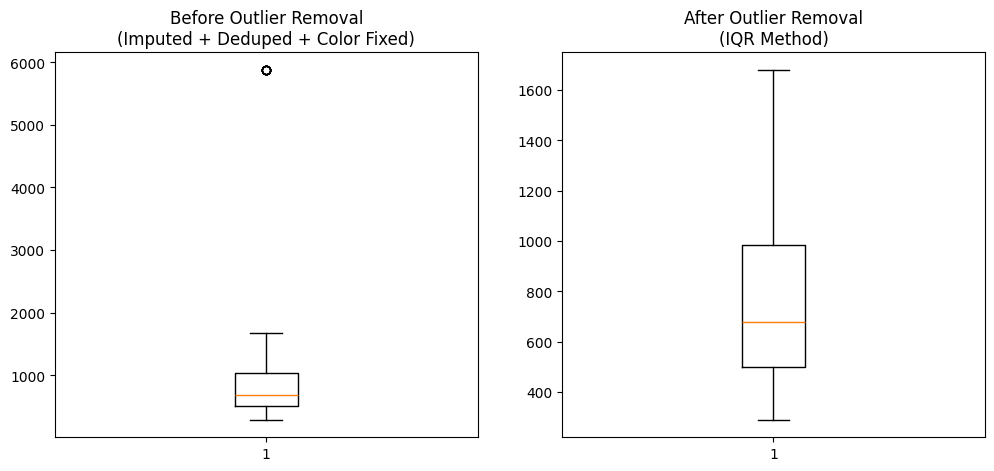

In [ ]:
# Write your code here

# Reload the corrupted data (with previous cleaning steps applied)
df_before = pd.read_sql_query("SELECT * FROM wine_corrupted", conn)

# Apply missing value imputation and duplicate removal (but not outlier removal)
df_before["alcohol"] = df_before["alcohol"].fillna(df_before["alcohol"].median())
df_before["magnesium"] = df_before["magnesium"].fillna(df_before["magnesium"].median())
df_before = df_before.drop_duplicates()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.boxplot(df_before["proline"].dropna())
plt.title("Before Outlier Removal\n")
plt.subplot(1, 2, 2)
plt.boxplot(df_no_outliers["proline"].dropna())
plt.title("After Outlier Removal\n")

plt.show()


## **TASK 8: Save Cleaned Data to Database**

Now that the data is cleaned, save it to a new table called `wine_cleaned` in the same SQLite database.

Use pandas' `.to_sql()` method with `if_exists='replace'` parameter.

In [13]:
# Write your code here

print("SAVING CLEANED DATA TO DATABASE")
print("="*50)

# Save to database
df_no_outliers.to_sql("wine_cleaned", conn, if_exists="replace", index=False)

print(f"✓ Cleaned data saved to 'wine_cleaned' table")
print(f"  Rows saved: {len(df)}")
print(f"  Columns: {len(df.columns)}")

SAVING CLEANED DATA TO DATABASE
✓ Cleaned data saved to 'wine_cleaned' table
  Rows saved: 174
  Columns: 14


## **TASK 9: Validate Cleaning with SQL**

Use SQL queries to compare the corrupted and cleaned datasets. Write queries to:

a) Count rows in both tables  
b) Compare distinct color values  
c) Compare average, min, and max values for `proline`  
d) Count missing values (NULL) in both tables

**Hint:** Use `COUNT(column)` to count non-NULL values, and `COUNT(*)` to count all rows. The difference reveals NULL counts.

In [14]:
# Write your code here

print("SQL VALIDATION: COMPARING CORRUPTED VS CLEANED DATA")
print("="*60)

# a) Compare row counts
print("\na) ROW COUNTS:")
corrupted_count = ...
cleaned_count = ...
print(f"   Corrupted: {corrupted_count} rows")
print(f"   Cleaned:   {cleaned_count} rows")
print(f"   Removed:   {corrupted_count - cleaned_count} rows ({((corrupted_count-cleaned_count)/corrupted_count)*100:.1f}%)")

# b) Compare distinct color values
print("\nb) DISTINCT COLOR VALUES:")
corrupted_colors = ...
cleaned_colors = ...
print(f"   Corrupted: {corrupted_colors}")
print(f"   Cleaned:   {cleaned_colors}")

# c) Compare proline statistics
print("\nc) PROLINE STATISTICS:")
corr_avg, corr_min, corr_max = ...
clean_avg, clean_min, clean_max = ...
print(f"   Corrupted - Avg: {corr_avg:.2f}, Min: {corr_min:.2f}, Max: {corr_max:.2f}")
print(f"   Cleaned   - Avg: {clean_avg:.2f}, Min: {clean_min:.2f}, Max: {clean_max:.2f}")

# d) Count missing values
print("\nd) MISSING VALUES (NULL):")
# For corrupted table
corr_alcohol_nulls, corr_mag_nulls = ...
# For cleaned table
clean_alcohol_nulls, clean_mag_nulls = ...

print(f"   Corrupted - alcohol: {corr_alcohol_nulls} NULLs, magnesium: {corr_mag_nulls} NULLs")
print(f"   Cleaned   - alcohol: {clean_alcohol_nulls} NULLs, magnesium: {clean_mag_nulls} NULLs")

print("\n" + "="*60)
print("✓ VALIDATION COMPLETE: Data cleaning successfully verified!")

SQL VALIDATION: COMPARING CORRUPTED VS CLEANED DATA

a) ROW COUNTS:
   Corrupted: Ellipsis rows
   Cleaned:   Ellipsis rows


TypeError: unsupported operand type(s) for -: 'ellipsis' and 'ellipsis'

## **TASK 10: Final Analysis - Create Summary Report**

Create a comprehensive summary report using SQL that shows:

1. Statistics for each wine color in the cleaned dataset
2. A table showing count, average alcohol, and average proline by color

Use SQL GROUP BY groupby operations.

In [15]:
# Write your code here

print("FINAL SUMMARY REPORT: CLEANED WINE DATASET")
print("="*60)

# Using SQL GROUP BY
query = """
SELECT
    color,
    COUNT(*) AS count,
    AVG(alcohol) AS avg_alcohol,
    AVG(proline) AS avg_proline
FROM wine_cleaned
GROUP BY color
ORDER BY count DESC;
"""

summary_df = pd.read_sql_query(query, conn)
print("\nWine Statistics by Color:")
print(summary_df.to_string(index=False))

print("\n" + "="*60)
print(f"Total wines in cleaned dataset: {summary_df['count'].sum()}")
print(f"Overall average alcohol: {df['alcohol'].mean():.2f}")
print(f"Overall average proline: {df['proline'].mean():.2f}")

FINAL SUMMARY REPORT: CLEANED WINE DATASET

Wine Statistics by Color:
color  count  avg_alcohol  avg_proline
white     69    12.364348   520.289855
  red     60    13.644000  1105.700000
 rosé     45    13.113778   627.666667

Total wines in cleaned dataset: 174
Overall average alcohol: 13.00
Overall average proline: 749.93


## **Visualize Before and After**


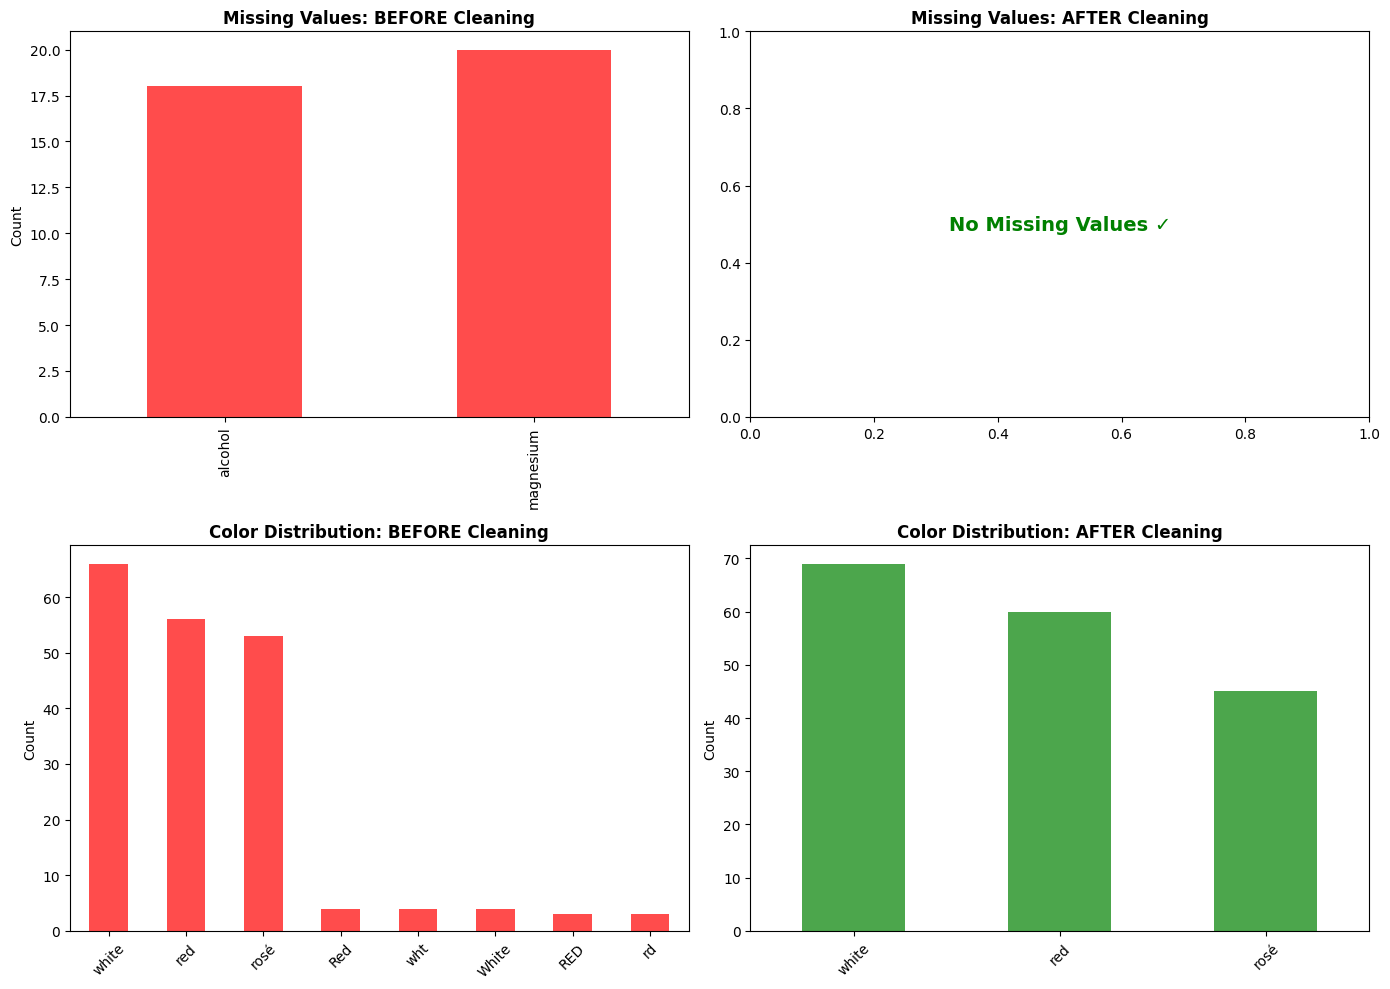

Visualization shows the dramatic improvement in data quality!


In [16]:
# Reload corrupted data for comparison
df_corrupted_viz = pd.read_sql_query('SELECT * FROM wine_corrupted', conn)
df_cleaned_viz = pd.read_sql_query('SELECT * FROM wine_cleaned', conn)

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Missing values comparison
missing_before = df_corrupted_viz.isnull().sum()[df_corrupted_viz.isnull().sum() > 0]
missing_after = df_cleaned_viz.isnull().sum()[df_cleaned_viz.isnull().sum() > 0]
if len(missing_before) > 0:
    missing_before.plot(kind='bar', ax=axes[0, 0], color='red', alpha=0.7)
    axes[0, 0].set_title('Missing Values: BEFORE Cleaning', fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_xlabel('')
else:
    axes[0, 0].text(0.5, 0.5, 'No Missing Values', ha='center', va='center', transform=axes[0, 0].transAxes)
    axes[0, 0].set_title('Missing Values: BEFORE Cleaning', fontweight='bold')

if len(missing_after) > 0:
    missing_after.plot(kind='bar', ax=axes[0, 1], color='green', alpha=0.7)
    axes[0, 1].set_title('Missing Values: AFTER Cleaning', fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xlabel('')
else:
    axes[0, 1].text(0.5, 0.5, 'No Missing Values ✓', ha='center', va='center', 
                    transform=axes[0, 1].transAxes, fontsize=14, color='green', fontweight='bold')
    axes[0, 1].set_title('Missing Values: AFTER Cleaning', fontweight='bold')

# 2. Color value distribution
df_corrupted_viz['color'].value_counts().plot(kind='bar', ax=axes[1, 0], color='red', alpha=0.7)
axes[1, 0].set_title('Color Distribution: BEFORE Cleaning', fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

df_cleaned_viz['color'].value_counts().plot(kind='bar', ax=axes[1, 1], color='green', alpha=0.7)
axes[1, 1].set_title('Color Distribution: AFTER Cleaning', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Visualization shows the dramatic improvement in data quality!")

## **Clean Up**

Always close database connections when finished.

In [17]:
# Close the database connection
conn.close()
print("Database connection closed.")
print("\n🎉 Assignment complete! Great work on cleaning the data!")

Database connection closed.

🎉 Assignment complete! Great work on cleaning the data!
